# Feature Engineering — Malaria Outbreak Prediction
### MSc AI Project | Climate Change & Malaria

This notebook transforms raw data into model-ready features.
We keep it simple: a few meaningful features, clearly explained.


In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn imbalanced-learn


---
## 1. Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import os, warnings
warnings.filterwarnings("ignore")

print("Libraries loaded ✅")


Libraries loaded ✅


---
## 2. Load the Dataset


In [3]:
df = pd.read_csv(r"C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\Data\Processed\malaria_final_dataset.csv")

print(f"Shape  : {df.shape}")
print(f"Years  : {df.Year.min()} – {df.Year.max()}")
print(f"Countries: {df['Country Name'].nunique()}")
df.head()


Shape  : (2402, 9)
Years  : 2000 – 2022
Countries: 106


,Country Name,Country Code,Year,Malaria_Incidence,Precipitation_mm,Pop_Density,GDP_per_Capita,Temp_Annual_Mean_C,Temp_GrowingSeason_Mean_C
0,Afghanistan,AFG,2000,84.48,327.0,30.863847,308.318270,15.237250,15.827333
1,Afghanistan,AFG,2001,83.83,327.0,31.099929,277.118051,15.589417,15.732667
2,Afghanistan,AFG,2002,83.79,327.0,32.776961,338.139974,15.333917,15.128000
3,Afghanistan,AFG,2003,70.81,327.0,34.854344,346.071627,14.737250,14.390833
4,Afghanistan,AFG,2004,39.41,327.0,36.123230,338.637274,15.619500,15.063500


---
## 3. Create the Target Variable

We want to predict: **will there be an outbreak NEXT year?**

So we shift malaria incidence forward by 1 year within each country.
If next year's incidence is above the 75th percentile → label = 1 (outbreak).


In [4]:
# Sort chronologically within each country
df = df.sort_values(["Country Name", "Year"]).reset_index(drop=True)

# Threshold: top 25% of incidence = outbreak
threshold = df["Malaria_Incidence"].quantile(0.75)
print(f"Outbreak threshold (75th percentile): {threshold:.1f} cases per 1,000")

# Shift incidence by -1 within each country to get next year's value
df["Next_Year_Incidence"] = df.groupby("Country Name")["Malaria_Incidence"].shift(-1)

# Binary label: 1 = outbreak next year, 0 = no outbreak
df["Outbreak_Label"] = (df["Next_Year_Incidence"] >= threshold).astype(int)

# Class distribution
counts = df["Outbreak_Label"].value_counts()
print(f"No Outbreak (0): {counts[0]}  |  Outbreak (1): {counts[1]}")


Outbreak threshold (75th percentile): 208.5 cases per 1,000
No Outbreak (0): 1834  |  Outbreak (1): 568


---
## 4. Lag Features

A **lag feature** is simply last year's value.

Why? Because malaria outbreaks have momentum — if incidence was high 
last year, it is likely to remain high this year.

We create:
-  — incidence 1 year ago
-     — temperature 1 year ago


In [5]:
grp = df.groupby("Country Name")

df["Malaria_Lag1"] = grp["Malaria_Incidence"].shift(1)
df["Temp_Lag1"]    = grp["Temp_Annual_Mean_C"].shift(1)

# Quick check: Angola example
print("Angola — last 4 years:")
print(df[df["Country Name"]=="Angola"][["Year","Malaria_Incidence","Malaria_Lag1"]].tail(4).to_string(index=False))


Angola — last 4 years:
 Year  Malaria_Incidence  Malaria_Lag1
 2019             243.10        232.44
 2020             244.53        243.10
 2021             258.61        244.53
 2022             260.09        258.61


---
## 5. Rolling Average

A **3-year rolling mean** smooths out year-to-year noise.
It tells the model: *what has the trend been over the past 3 years?*


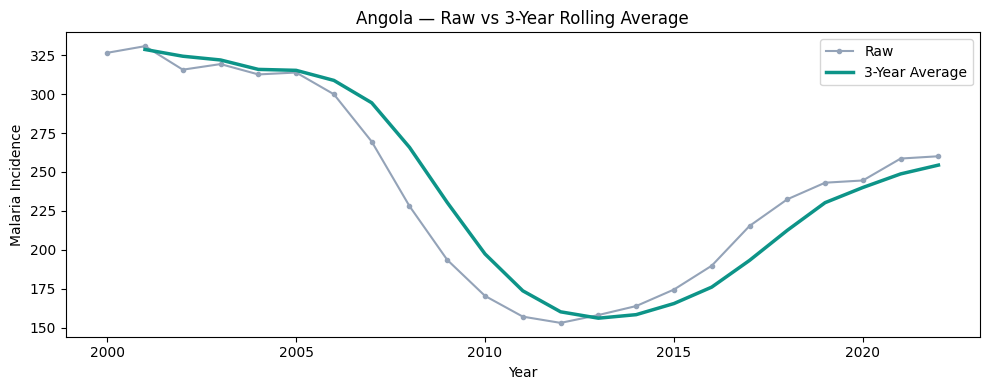

In [6]:
df["Malaria_Roll3"] = (
    df.groupby("Country Name")["Malaria_Incidence"]
    .transform(lambda x: x.rolling(window=3, min_periods=2).mean())
)

# Plot: raw vs smoothed for one country
sub = df[df["Country Name"]=="Angola"]
plt.figure(figsize=(10,4))
plt.plot(sub["Year"], sub["Malaria_Incidence"], label="Raw", color="#94A3B8", marker="o", markersize=3)
plt.plot(sub["Year"], sub["Malaria_Roll3"],     label="3-Year Average", color="#0D9488", linewidth=2.5)
plt.title("Angola — Raw vs 3-Year Rolling Average")
plt.xlabel("Year"); plt.ylabel("Malaria Incidence"); plt.legend()
plt.tight_layout(); plt.show()


---
## 6. One Interaction Feature

Warm AND wet = best mosquito breeding conditions.
We capture this by multiplying temperature × precipitation.


In [7]:
df["Temp_x_Precip"] = df["Temp_Annual_Mean_C"] * df["Precipitation_mm"]

print("Correlation with Outbreak_Label:")
features = ["Malaria_Incidence","Temp_Annual_Mean_C","Precipitation_mm",
            "GDP_per_Capita","Malaria_Lag1","Malaria_Roll3","Temp_x_Precip"]
corr = df[features + ["Outbreak_Label"]].corr()["Outbreak_Label"].drop("Outbreak_Label")
print(corr.sort_values(ascending=False).round(3).to_string())


Correlation with Outbreak_Label:
Malaria_Incidence     0.898
Malaria_Roll3         0.891
Malaria_Lag1          0.888
Temp_Annual_Mean_C    0.248
Temp_x_Precip         0.072
Precipitation_mm      0.036
GDP_per_Capita       -0.252


---
## 7. Define Final Feature Set

We keep **9 features** — enough to be informative, simple enough to explain.


In [8]:
FEATURES = [
    "Malaria_Incidence",       # current year incidence
    "Temp_Annual_Mean_C",       # temperature
    "Precipitation_mm",         # rainfall
    "GDP_per_Capita",           # economic capacity
    "Pop_Density",              # population exposure
    "Malaria_Lag1",             # last year incidence
    "Temp_Lag1",                # last year temperature
    "Malaria_Roll3",            # 3-year trend
    "Temp_x_Precip",            # climate interaction
]
TARGET = "Outbreak_Label"

# Drop rows where label or features are NaN
df_model = df[FEATURES + [TARGET, "Country Name", "Year"]].dropna()

print(f"Final dataset: {df_model.shape[0]} rows × {len(FEATURES)} features")
print(f"Outbreak rate: {df_model[TARGET].mean():.1%}")


Final dataset: 2296 rows × 9 features
Outbreak rate: 23.3%


---
## 8. Train / Validation / Test Split

We split **by year** — never randomly — to avoid using future data to predict the past.

| Split | Years | Purpose |
|-------|-------|---------|
| Train | 2000–2016 | Fit the model |
| Validation | 2017–2019 | Tune hyperparameters |
| Test | 2020–2022 | Final honest evaluation |


In [9]:
X = df_model[FEATURES]
y = df_model[TARGET]
years = df_model["Year"]

X_train = X[years <= 2016];  y_train = y[years <= 2016]
X_val   = X[(years > 2016) & (years <= 2019)]; y_val = y[(years > 2016) & (years <= 2019)]
X_test  = X[years > 2019];  y_test  = y[years > 2019]

print(f"Train : {len(X_train)} rows")
print(f"Val   : {len(X_val)} rows")
print(f"Test  : {len(X_test)} rows")


Train : 1674 rows
Val   : 318 rows
Test  : 304 rows


---
## 9. Scale Features

Logistic Regression needs scaled features (mean=0, std=1).
We fit the scaler on training data only — never on val or test.


In [10]:
scaler = StandardScaler()
scaler.fit(X_train)                          # learn mean & std from train only

X_train_sc = pd.DataFrame(scaler.transform(X_train), columns=FEATURES)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),   columns=FEATURES)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURES)

print("Scaling done ✅")
print("Train mean (should be ~0):", X_train_sc.mean().round(2).values)


Scaling done ✅
Train mean (should be ~0): [ 0.  0. -0. -0.  0.  0.  0. -0.  0.]


---
## 10. Handle Class Imbalance (SMOTE)

Outbreaks are rare — the dataset is imbalanced.
SMOTE creates synthetic minority-class examples so the model sees enough outbreaks to learn from.
Applied to **training data only**.


In [11]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print(f"Before SMOTE → class 0: {(y_train==0).sum()}  class 1: {(y_train==1).sum()}")
print(f"After  SMOTE → class 0: {(y_train_bal==0).sum()}  class 1: {(y_train_bal==1).sum()}")


Before SMOTE → class 0: 1262  class 1: 412
After  SMOTE → class 0: 1262  class 1: 1262


---
## 11. Export


In [13]:
EXPORT = r"C:\Users\Likhita Kolli\OneDrive - Hochschule Luzern\SEM_2\AI\Data\Processed\feature_store1"
os.makedirs(EXPORT, exist_ok=True)

X_train_bal.to_csv(f"{EXPORT}/X_train_smote.csv",  index=False)
pd.Series(y_train_bal, name=TARGET).to_csv(f"{EXPORT}/y_train_smote.csv", index=False)

X_train_sc.to_csv(f"{EXPORT}/X_train_scaled.csv", index=False)
X_val_sc.to_csv(  f"{EXPORT}/X_val_scaled.csv",   index=False)
X_test_sc.to_csv( f"{EXPORT}/X_test_scaled.csv",  index=False)

X_train.to_csv(f"{EXPORT}/X_train.csv", index=False)
X_val.to_csv(  f"{EXPORT}/X_val.csv",   index=False)
X_test.to_csv( f"{EXPORT}/X_test.csv",  index=False)

y_train.to_csv(f"{EXPORT}/y_train.csv", index=False)
y_val.to_csv(  f"{EXPORT}/y_val.csv",   index=False)
y_test.to_csv( f"{EXPORT}/y_test.csv",  index=False)

# Save scaler parameters
pd.DataFrame({"feature": FEATURES, "mean": scaler.mean_, "std": scaler.scale_}
             ).to_csv(f"{EXPORT}/scaler_params.csv", index=False)

# Save feature list for pipeline
import json
with open(f"{EXPORT}/feature_cols.json", "w") as f:
    json.dump(FEATURES, f)

print("All files saved to feature_store/ ✅")
for fname in sorted(os.listdir(EXPORT)):
    print(f"  {fname}")


All files saved to feature_store/ ✅
  X_test.csv
  X_test_scaled.csv
  X_train.csv
  X_train_scaled.csv
  X_train_smote.csv
  X_val.csv
  X_val_scaled.csv
  feature_cols.json
  scaler_params.csv
  y_test.csv
  y_train.csv
  y_train_smote.csv
  y_val.csv


---
## Summary

| Step | What we did |
|------|------------|
| Target | Shift incidence +1 year → binary outbreak label |
| Lag feature | Last year's malaria incidence & temperature |
| Rolling mean | 3-year average incidence trend |
| Interaction | Temperature × Precipitation |
| Scaling | StandardScaler fit on train only |
| Imbalance | SMOTE on training set only |
| **Total features** | **9** |

Ready for model training →
